In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
# Chargement des données
df = pd.read_csv('../data/raw/train.csv')

# Copie du dataset
df_model = df.copy()

# Conversion de la date
df_model['date'] = pd.to_datetime(df_model['date'])

# Tri chronologique pour chaque série magasin-article
df_model = df_model.sort_values(
    ['store', 'item', 'date']
).reset_index(drop=True)

# Variables calendaires
df_model['month'] = df_model['date'].dt.month
df_model['day_of_week'] = df_model['date'].dt.dayofweek

df_model.head()

,date,store,item,sales,month,day_of_week
0,2013-01-01,1,1,13,1,1
1,2013-01-02,1,1,11,1,2
2,2013-01-03,1,1,14,1,3
3,2013-01-04,1,1,13,1,4
4,2013-01-05,1,1,10,1,5


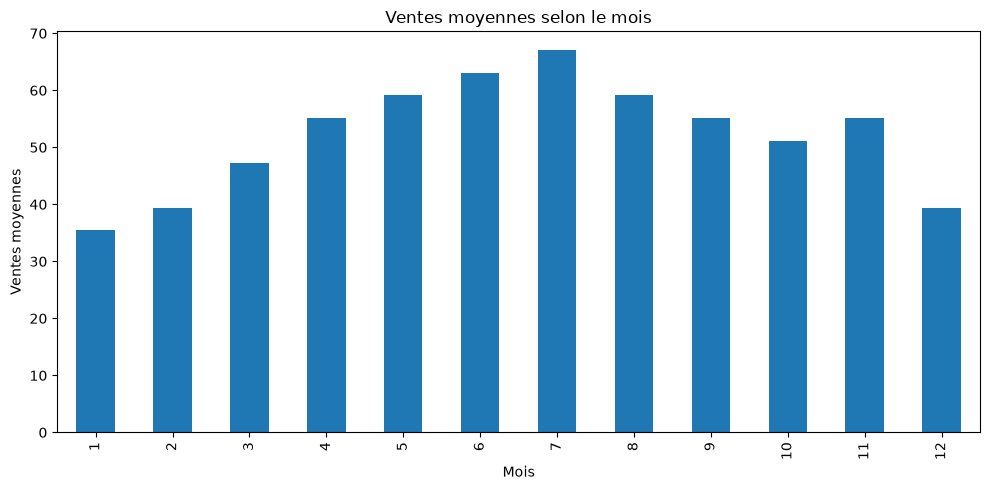

In [2]:
#Observons les ventes selon le mois
ventes_par_mois = df_model.groupby('month')['sales'].mean()
ventes_par_mois
#Visualisation
plt.figure(figsize=(10, 5))

ventes_par_mois.plot(kind="bar")

plt.title("Ventes moyennes selon le mois")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")

plt.tight_layout()
plt.savefig('graphique_ventes_moyennes_mois.png',dpi=300,bbox_inches='tight')
plt.show()

In [3]:
# Nous allons créer la variable retard (lag)
# Combien d'articles ont éte vendus hier
df_model["sales_lag_1"]=(df_model.groupby(['store','item',])['sales'].shift(1))
df_model[['date','store','item','sales','sales_lag_1']].head(23)

,date,store,item,sales,sales_lag_1
0,2013-01-01,1,1,13,NaN
1,2013-01-02,1,1,11,13.0
2,2013-01-03,1,1,14,11.0
3,2013-01-04,1,1,13,14.0
4,2013-01-05,1,1,10,13.0
5,2013-01-06,1,1,12,10.0
6,2013-01-07,1,1,10,12.0
7,2013-01-08,1,1,9,10.0
8,2013-01-09,1,1,12,9.0
9,2013-01-10,1,1,9,12.0


In [4]:
df_model["sales_lag_7"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .shift(7)
)

df_model["sales_lag_14"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .shift(14)
)
df_model[['date','store','item','sales','sales_lag_1','sales_lag_7','sales_lag_14']].head(23)


,date,store,item,sales,sales_lag_1,sales_lag_7,sales_lag_14
0,2013-01-01,1,1,13,NaN,NaN,NaN
1,2013-01-02,1,1,11,13.0,NaN,NaN
2,2013-01-03,1,1,14,11.0,NaN,NaN
3,2013-01-04,1,1,13,14.0,NaN,NaN
4,2013-01-05,1,1,10,13.0,NaN,NaN
5,2013-01-06,1,1,12,10.0,NaN,NaN
6,2013-01-07,1,1,10,12.0,NaN,NaN
7,2013-01-08,1,1,9,10.0,13.0,NaN
8,2013-01-09,1,1,12,9.0,11.0,NaN
9,2013-01-10,1,1,9,12.0,14.0,NaN


In [9]:
# Ajout des moyennes mobiles sur 7,14 et 30 jours
# Les ventes du jour à prédire ne sont jamais utilisées.

df_model["rolling_mean_14"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

df_model["rolling_mean_30"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)
df_model["rolling_mean_7"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

# Variables utilisées par le modèle
features = [
    "month",
    "day_of_week",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

# Suppression des lignes incomplètes
df_model = df_model.dropna().copy()

print("Variables utilisées par le modèle :")
print(features)

print("\nNombre de variables :", len(features))

Variables utilisées par le modèle :
['month', 'day_of_week', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']

Nombre de variables : 8


In [10]:
df_model = df_model.dropna().copy()
df_model.isnull().sum()

date               0
store              0
item               0
sales              0
month              0
day_of_week        0
sales_lag_1        0
sales_lag_7        0
sales_lag_14       0
rolling_mean_14    0
rolling_mean_30    0
rolling_mean_7     0
dtype: int64

In [11]:
# Vérification de l'ordre chronologique
df_model = df_model.sort_values(
    ['store', 'item', 'date']
).reset_index(drop=True)

df_model.head()

,date,store,item,sales,month,day_of_week,sales_lag_1,sales_lag_7,sales_lag_14,rolling_mean_14,rolling_mean_30,rolling_mean_7
0,2013-03-02,1,1,13,3,5,15.0,15.0,7.0,10.428571,11.666667,10.857143
1,2013-03-03,1,1,20,3,6,13.0,11.0,11.0,10.857143,11.666667,10.571429
2,2013-03-04,1,1,14,3,0,20.0,7.0,10.0,11.500000,11.966667,11.857143
3,2013-03-05,1,1,13,3,1,14.0,9.0,10.0,11.785714,11.733333,12.857143
4,2013-03-06,1,1,17,3,2,13.0,9.0,7.0,12.000000,11.666667,13.428571


In [12]:
# Variables explicatives et variable cible

X = df_model[features]
y = df_model["sales"]

print("Variables prédictives :")
print(features)

print("\nDimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Variables prédictives :
['month', 'day_of_week', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']

Dimensions de X : (883000, 8)
Dimensions de y : (883000,)


In [13]:
# Séparation temporelle des données

dates = sorted(df_model["date"].unique())

split_date = dates[int(len(dates) * 0.8)]

train_data = df_model[
    df_model["date"] < split_date
].copy()

test_data = df_model[
    df_model["date"] >= split_date
].copy()

print("Période d'entraînement :")
print(train_data["date"].min(), "à", train_data["date"].max())

print("\nPériode de test :")
print(test_data["date"].min(), "à", test_data["date"].max())

print("\nDate de séparation :", split_date)

Période d'entraînement :
2013-03-02 00:00:00 à 2017-01-11 00:00:00

Période de test :
2017-01-12 00:00:00 à 2017-12-31 00:00:00

Date de séparation : 2017-01-12 00:00:00


In [14]:
# Préparation des données d'entraînement et de test

X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)

print("\nDernière date train :", train_data["date"].max())
print("Première date test :", test_data["date"].min())

print(
    "Chevauchement temporel :",
    train_data["date"].max() >= test_data["date"].min()
)

Taille X_train : (706000, 8)
Taille X_test : (177000, 8)

Dernière date train : 2017-01-11 00:00:00
Première date test : 2017-01-12 00:00:00
Chevauchement temporel : False


In [15]:
#vérifions la présence des magasins et articles print("Magasins train :", train_data["store"].nunique())
print("Magasins train :", train_data["store"].nunique())
print("Magasins test  :", test_data["store"].nunique())

print("Articles train :", train_data["item"].nunique())
print("Articles test  :", test_data["item"].nunique())

Magasins train : 10
Magasins test  : 10
Articles train : 50
Articles test  : 50


In [18]:
print("Random Forest amélioré")

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=15,
    n_jobs=-1,
    max_depth=15,
    min_samples_leaf=2
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

Random Forest amélioré
Random Forest
MAE : 6.4051355602691915
RMSE : 8.357625431885394
R² : 0.930289057402104


In [17]:
#Modèle : Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE :", rmse_gb)
print("R² :", r2_gb)



Gradient Boosting
MAE : 6.601952405777514
RMSE : 8.614161706850991
R² : 0.9259438400109302


In [19]:
print('Comparaison des modèles')
Comparaison = pd.DataFrame({"Modèles":
["Random Forest Regressor","Gradient Boosting Regressor"],"MAE":[mae_rf,mae_gb],'RMSE':[rmse_rf,rmse_gb],'R²':[r2_rf,r2_gb]})
Comparaison

Comparaison des modèles


,Modèles,MAE,RMSE,R²
0,Random Forest Regressor,6.405136,8.357625,0.930289
1,Gradient Boosting Regressor,6.601952,8.614162,0.925944


In [20]:
print(f"Le modèle retenu est le Random Forest Regressor avec un score R² de {r2_rf} , un MAE de {mae_rf} et un RMSE de {rmse_rf}")

Le modèle retenu est le Random Forest Regressor avec un score R² de 0.930289057402104 , un MAE de 6.4051355602691915 et un RMSE de 8.357625431885394


Visualisation des modèles : réelle vs prédiction
Random Forest


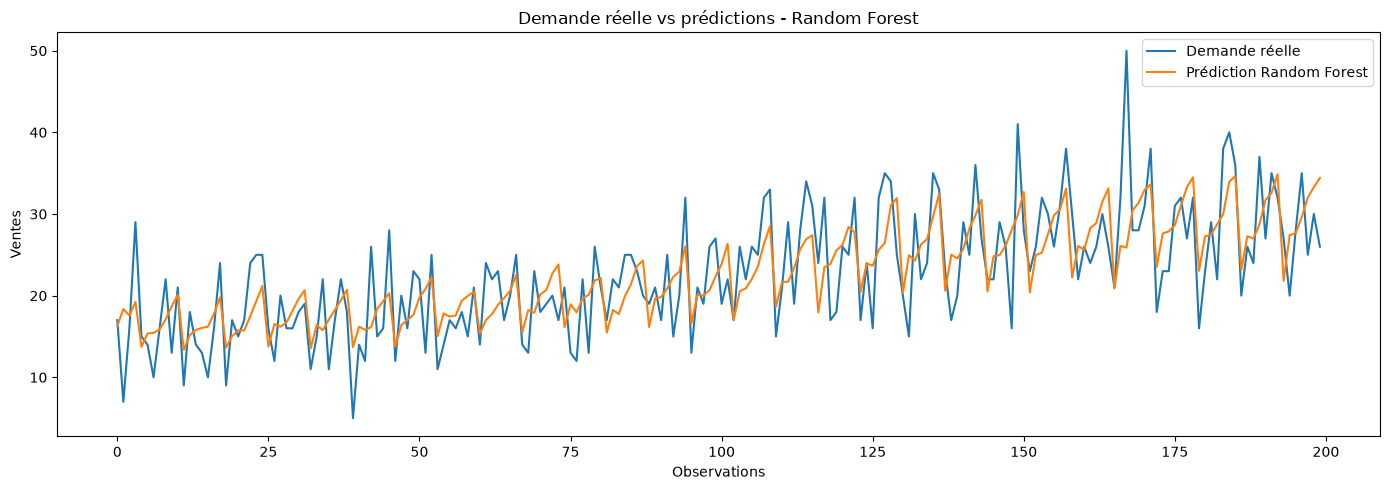

Gradient Boosting


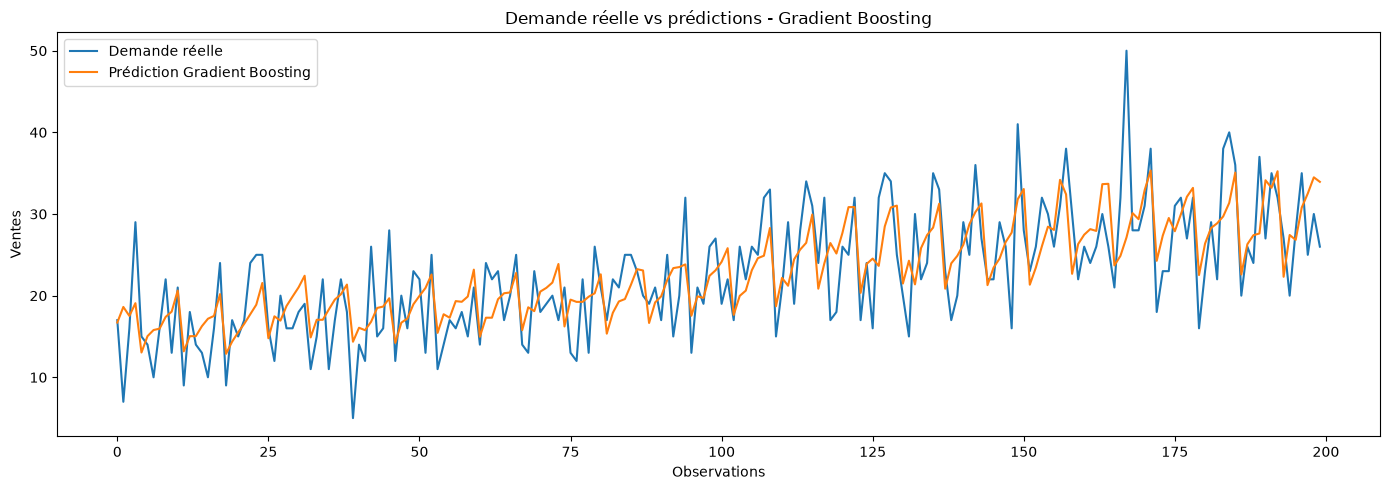

In [21]:
print('Visualisation des modèles : réelle vs prédiction')

print('Random Forest')
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:200].values,
    label="Demande réelle"
)

plt.plot(
    y_pred_rf[:200],
    label="Prédiction Random Forest"
)

plt.title("Demande réelle vs prédictions - Random Forest")
plt.xlabel("Observations")
plt.ylabel("Ventes")
plt.legend()

plt.tight_layout()
plt.show()


print("Gradient Boosting")
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:200].values,
    label="Demande réelle"
)

plt.plot(
    y_pred_gb[:200],
    label="Prédiction Gradient Boosting"
)

plt.title("Demande réelle vs prédictions - Gradient Boosting")
plt.xlabel("Observations")
plt.ylabel("Ventes")
plt.legend()

plt.tight_layout()
plt.show()


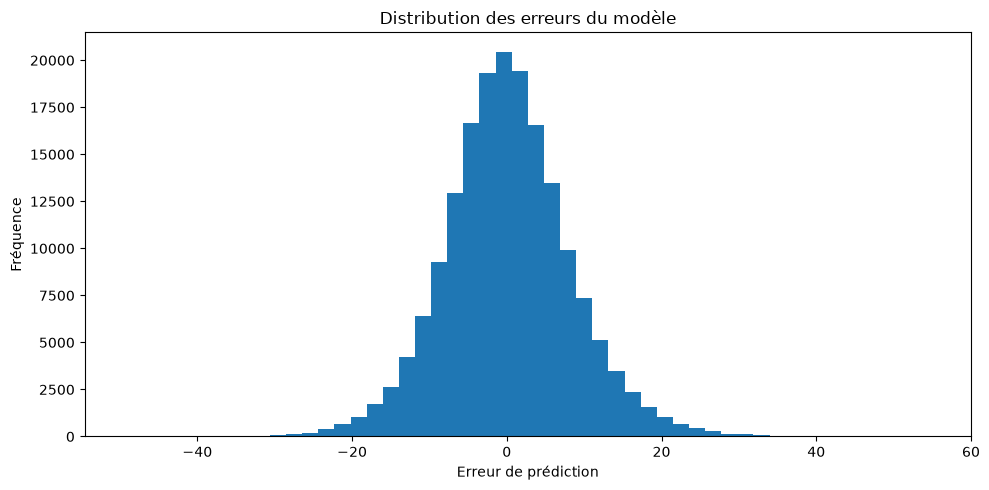

In [ ]:
#Distribution des erreurs du modèle

plt.figure(figsize=(10, 5))

plt.hist(comparaison["erreur"], bins=50)

plt.title("Distribution des erreurs du modèle")
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.savefig('distribution_erreur.png',dpi=300,bbox_inches='tight')
plt.show()
# cette visualisation est importante pour l'analyse du modèle:on cherche à comprendre si les erreurs sont
#plutôt petites et centrées autour de 0


In [23]:
print(len(features))
print(len(model_rf.feature_importances_))

8
8


Importance des variables du modèle final


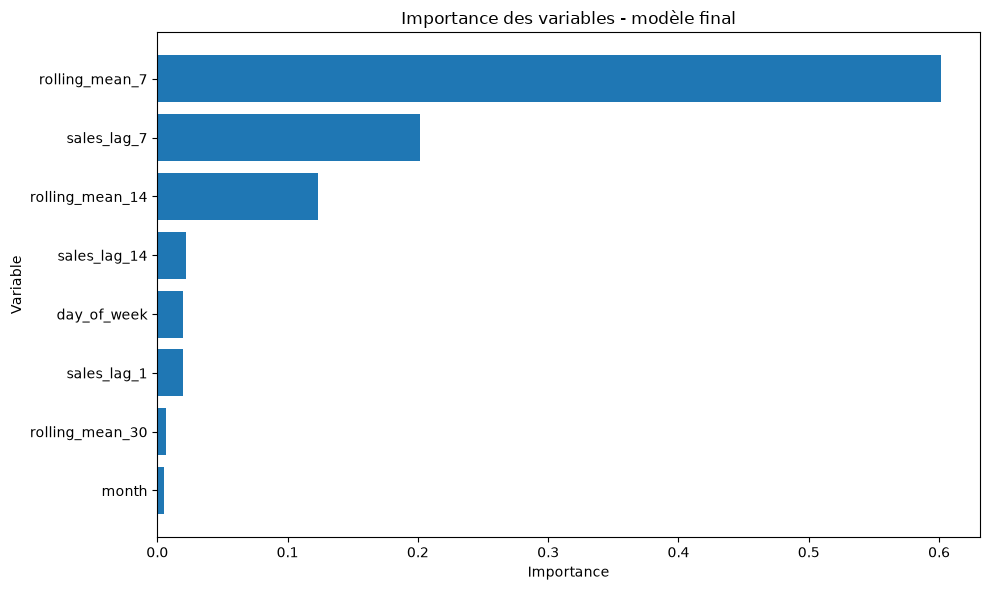

In [22]:
print('Importance des variables du modèle final')
importance_finale = pd.DataFrame({
    "Variable": features,
    "Importance": model_rf.feature_importances_
})

importance_finale = importance_finale.sort_values(
    "Importance",
    ascending=False
)

importance_finale
plt.figure(figsize=(10, 6))

plt.barh(
    importance_finale["Variable"],
    importance_finale["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Importance des variables - modèle final")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.savefig('importance_variable.png',dpi=300,bbox_inches='tight')
plt.show()
#c'est l'idée d'interprétation du modèle : nous cherchons à comprendre quelles informations
#ont contribué à la prédiction

In [24]:
#Nous allons maintenant sauvegarder le modèle
import joblib

joblib.dump(
    model_rf,
    "../models/modele_demande_random_forest.joblib",compress=3
)
#vérification 
import os

print(
    os.path.exists(
        "../models/modele_demande_random_forest.joblib"
    )
)

True


In [26]:
print('sauvegarde des variables ')
import json

metadata = {
    "features": features,
    "target": "sales",
    "model": "Random Forest Regressor",
    "lags": [1, 7, 14],
    "rolling_windows": [7, 14, 30]
}

with open("../models/metadata.json", "w", encoding="utf-8") as fichier:
    json.dump(metadata, fichier, indent=4)

sauvegarde des variables 


In [27]:
import joblib
joblib.dump(model_rf, '../models/modele_demande_random_forest.joblib', compress=0)
print('Modèle chargé avec succès')

Modèle chargé avec succès


In [28]:
prediction = model_rf.predict(X_test)

In [29]:
display(prediction)

array([16.31968759, 18.35627712, 17.56348113, ..., 63.62675048,
       69.3630424 , 59.59271605], shape=(177000,))